# Calibrating DevFromMeanElev against manually mapped dolines

`DepthInSink` (notebooks 01/02) conflates slope roughness with real dolines on this sloped, complex terrain. `DevFromMeanElev` (local relief relative to a neighborhood window) should cancel out the regional slope, but the right window size depends on real doline scale, which we now have 13 manually mapped examples for (`data/manual/Sinkholes.shp`).

This notebook: compute DevFromMeanElev at several window sizes, sample it at the manual points vs. random background locations, and see which window size actually separates the two — exploration/calibration, not a final method yet.

In [1]:
import os
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("pyproject.toml not found in any parent directory")


os.chdir(_find_repo_root(Path.cwd()))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from master_thesis.dolines import compute_dev_from_mean_elev, random_points_in_polygon, sample_raster

DATE = "20250820"
CLIPPED_DEM = Path(f"data/interim/{DATE}_terra_ppk_lidar_dsm_clip.tif")
AOI = Path(f"data/raw/{DATE}/{DATE}_aoi.gpkg")
MANUAL_POINTS = Path("data/manual/Sinkholes.shp")
INTERIM = Path("data/interim")
FIGURES = Path("outputs/figures")

# window widths in metres -> odd pixel counts at 5 cm resolution
WINDOW_WIDTHS_M = [0.5, 1, 2, 3, 5, 8]
PX_SIZE_M = 0.05
N_BACKGROUND = 200
SEED = 0

In [2]:
aoi = gpd.read_file(AOI)
manual_points = gpd.read_file(MANUAL_POINTS).to_crs(aoi.crs)
print(f"{len(manual_points)} manually mapped points, crs now {manual_points.crs}")

background = random_points_in_polygon(
    aoi.union_all(),
    n=N_BACKGROUND,
    crs=aoi.crs,
    exclude=manual_points.geometry,
    exclude_buffer_m=2.0,
    seed=SEED,
)
print(f"{len(background)} background points sampled")

13 manually mapped points, crs now EPSG:32632
200 background points sampled


In [3]:
records = []
for width_m in WINDOW_WIDTHS_M:
    filter_px = int(round(width_m / PX_SIZE_M))
    filter_px += 1 - filter_px % 2  # force odd

    dev_path = INTERIM / f"{CLIPPED_DEM.stem}_dev{filter_px}.tif"
    if not dev_path.exists():
        compute_dev_from_mean_elev(CLIPPED_DEM, dev_path, filter_px)

    manual_vals = sample_raster(dev_path, manual_points)
    background_vals = sample_raster(dev_path, background)

    for val in manual_vals:
        records.append({"window_m": width_m, "group": "manual doline", "dev_m": val})
    for val in background_vals:
        records.append({"window_m": width_m, "group": "background", "dev_m": val})

results = pd.DataFrame(records)
results.groupby(["window_m", "group"])["dev_m"].describe()[["mean", "std", "min", "50%", "max"]]

mean       std       min       50%       max
window_m group                                                          
0.5      background     0.011161  0.227823 -0.772315  0.024395  0.798552
         manual doline -0.285917  0.418069 -1.286580 -0.101670  0.020172
1.0      background     0.007329  0.229606 -0.673260  0.011723  0.892547
         manual doline -0.407765  0.600757 -1.726602 -0.171244  0.184511
2.0      background     0.011729  0.229518 -0.784096  0.006958  0.844949
         manual doline -0.623794  0.779060 -2.346908 -0.421277  0.041079
3.0      background     0.009485  0.240920 -1.034627  0.000170  0.829259
         manual doline -0.740627  0.762883 -2.178639 -0.657721  0.058227
5.0      background     0.000963  0.282952 -1.344291  0.003260  1.015386
         manual doline -0.906448  0.755393 -2.392706 -0.939001  0.087207
8.0      background     0.002397  0.326610 -1.306679 -0.000233  1.126456
         manual doline -0.998212  0.730118 -2.205461 -0.879882  0.019252

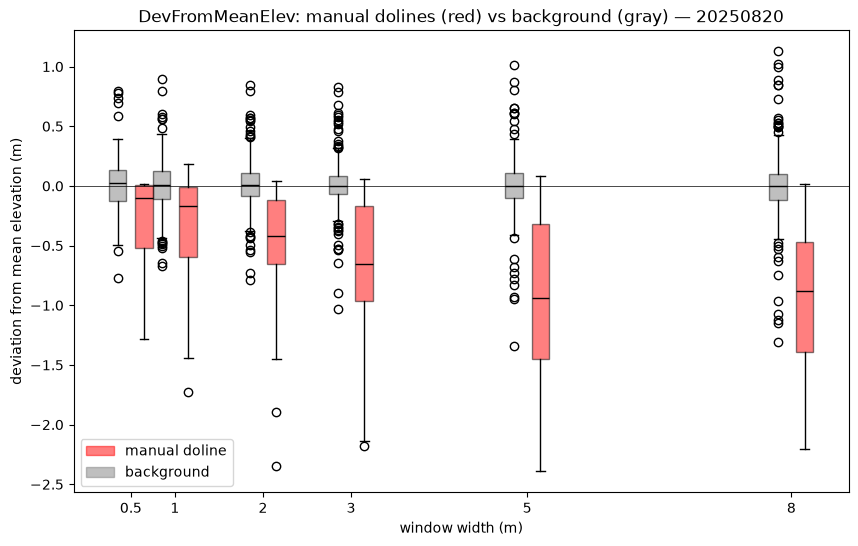

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
for group, color in (("background", "gray"), ("manual doline", "red")):
    data = [results.loc[(results.window_m == w) & (results.group == group), "dev_m"] for w in WINDOW_WIDTHS_M]
    positions = [w + (0.15 if group == "manual doline" else -0.15) for w in WINDOW_WIDTHS_M]
    ax.boxplot(data, positions=positions, widths=0.2, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5), medianprops=dict(color="black"))
ax.set_xticks(WINDOW_WIDTHS_M)
ax.set_xticklabels([str(w) for w in WINDOW_WIDTHS_M])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("window width (m)")
ax.set_ylabel("deviation from mean elevation (m)")
ax.set_title(f"DevFromMeanElev: manual dolines (red) vs background (gray) \u2014 {DATE}")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="red", alpha=0.5, label="manual doline"),
                    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.5, label="background")])
fig.savefig(FIGURES / f"{DATE}_dev_calibration.png", dpi=150, bbox_inches="tight")
plt.show()